# Pipeline 4 — Social Media Content Strategy (Explanatory)

## 1) Problem Framing

**Business question:** What characteristics of a social media post explain why it drives donations? The goal is to give the organization interpretable coefficients they can use as a permanent content strategy guide.

| | |
|---|---|
| **Type** | Explanatory |
| **Goal** | Quantify which content characteristics explain why some posts drive more donation referrals |
| **Target variable** | `donation_referrals` (continuous) |
| **Primary metric** | Adjusted R², coefficient significance |
| **Writes to** | `ml_predictions` + `ml_prediction_history` (org-level insight row) |

### Prediction vs Explanation

This is an **explanatory** pipeline. The organization doesn't need a black-box score — they need to know **what to post**. Coefficients like "ImpactStory posts generate ~28 more referrals than ThankYou posts" are sentences a non-technical director can act on. This is strategy, not prediction.

### Before-post vs After-post Features (Critical Distinction)

- **Before-post features** are things staff decide before publishing — platform, post type, content type, tone, timing, format. These are the **only features used as X variables**.
- **After-post features** are engagement metrics measured after publishing — shares, likes, impressions. These are **NOT used as X variables**. They appear in EDA to illustrate the engagement → donation cascade, but they cannot be used to predict future posts because staff cannot control them at publishing time.

### Difference from Pipeline 4B

This pipeline answers **"what to post."** Pipeline 4B answers **"when and where to post."** Different questions, different features, different algorithms, different outputs.

### What the org does with this

Results are published as a "Content Strategy Guide" in the admin social media section. Updated as new posts are logged. Also used on the public impact page and donor page.

> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsmodels scikit-learn scipy joblib python-dotenv sqlalchemy psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 2) Data Acquisition and Preparation
import json
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, f1_score,
)
from sklearn.feature_selection import VarianceThreshold
from dotenv import load_dotenv
from sqlalchemy import create_engine

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

# ---- Database connection ----
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in [".env", "ml/.env"]:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)


def fetch_table(table_name):
    """Fetch all rows from a PostgreSQL table into a DataFrame."""
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ---- Table / model path constants ----
TABLE_SOCIAL_MEDIA_POSTS = "social_media_posts"

PROJECT_ROOT = Path.cwd().resolve()
for _p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (_p / "models").exists():
        PROJECT_ROOT = _p
        break

MODELS_DIR = PROJECT_ROOT / "models"
MODEL_SOCIAL_CONTENT = MODELS_DIR / "social-media-content" / "model.sav"
MODEL_RUNS_SOCIAL_CONTENT = MODELS_DIR / "social-media-content" / "model.json"
MODEL_NAME_SOCIAL_CONTENT = "social-media-content"

# ---- Feature engineering (inlined from ml/social_media_content/features.py) ----
TARGET = "donation_referrals"

AFTER_POST_COLS = [
    "shares", "likes", "comments", "saves",
    "impressions", "reach", "engagement_rate",
]

_CATEGORICAL = [
    "platform", "post_type", "media_type",
    "sentiment_tone", "content_topic", "call_to_action_type", "day_of_week",
]

_BOOLEAN = [
    "features_resident_story", "has_call_to_action", "is_boosted",
]

_NUMERIC = [
    "boost_budget_php", "caption_length", "num_hashtags", "post_hour",
]


def build_features(raw):
    """Build the modelling-ready feature matrix from raw social_media_posts.

    Returns (X, y, eda_engagement).
    """
    df = raw.copy()

    # Target
    y = pd.to_numeric(df[TARGET], errors="coerce").fillna(0).astype(float)

    # After-post engagement (EDA only)
    eda_engagement = df[[c for c in AFTER_POST_COLS if c in df.columns]].apply(
        pd.to_numeric, errors="coerce"
    ).fillna(0)

    # Boolean features
    for col in _BOOLEAN:
        if col in df.columns:
            df[col] = (
                df[col].fillna(False).astype(str).str.strip().str.lower()
                .map({"true": 1, "1": 1, "yes": 1, "false": 0, "0": 0, "no": 0})
                .fillna(0).astype(int)
            )

    # Numeric features
    for col in _NUMERIC:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Categorical features (one-hot)
    for col in _CATEGORICAL:
        if col in df.columns:
            df[col] = df[col].fillna("None").astype(str)

    dummies = pd.get_dummies(
        df[[c for c in _CATEGORICAL if c in df.columns]],
        drop_first=False,
    )

    # Assemble X
    bool_cols = [c for c in _BOOLEAN if c in df.columns]
    num_cols = [c for c in _NUMERIC if c in df.columns]
    X = pd.concat([df[bool_cols + num_cols], dummies], axis=1)
    X.columns = pd.Index([str(c) for c in X.columns])

    return X, y, eda_engagement


RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [3]:
# Fetch data from database
raw = fetch_table(TABLE_SOCIAL_MEDIA_POSTS)
print(f"Total posts fetched: {len(raw)}")
print(f"Columns: {list(raw.columns)}")

Total posts fetched: 812
Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


In [4]:
# Build features using the shared feature engineering module
X, y, eda_engagement = build_features(raw)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget (donation_referrals) summary:")
print(y.describe())
print(f"\nPosts with referrals > 0: {(y > 0).sum()} ({(y > 0).mean()*100:.1f}%)")
print(f"\nFeature columns ({X.shape[1]}):")
print(list(X.columns))

X shape: (812, 52)
y shape: (812,)

Target (donation_referrals) summary:
count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64

Posts with referrals > 0: 522 (64.3%)

Feature columns (52):
['features_resident_story', 'has_call_to_action', 'is_boosted', 'boost_budget_php', 'caption_length', 'num_hashtags', 'post_hour', 'platform_Facebook', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube', 'post_type_Campaign', 'post_type_EducationalContent', 'post_type_EventPromotion', 'post_type_FundraisingAppeal', 'post_type_ImpactStory', 'post_type_ThankYou', 'media_type_Carousel', 'media_type_Photo', 'media_type_Reel', 'media_type_Text', 'media_type_Video', 'sentiment_tone_Celebratory', 'sentiment_tone_Emotional', 'sentiment_tone_Grateful', 'sentiment_tone_Hopeful', 'sentiment_tone_I

## 3) Exploration

We explore confirmed domain findings from the data. Remember: after-post engagement metrics (shares, likes, etc.) are shown here for context only — they are NOT used as model inputs.

### Confirmed findings to validate:
- `features_resident_story = True` averages 41.0 referrals vs 5.6 without — 7x difference
- ImpactStory posts average 36.4 referrals vs ThankYou at 0.8 — 45x range
- Reel averages 19.7 referrals vs Text at 7.0
- Emotional tone averages 18.1 referrals vs Grateful at 7.6
- WhatsApp averages 23.1 referrals, LinkedIn averages 4.3
- After-post: shares r=0.727 with referrals — strongest signal in the dataset
- Content decisions → engagement → donations (the cascade)

In [5]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 812, Features: 52

=== Outlier Check (numeric features) ===
  features_resident_story: 165 IQR outliers (20.3%)
  is_boosted: 127 IQR outliers (15.6%)
  boost_budget_php: 127 IQR outliers (15.6%)
  caption_length: 44 IQR outliers (5.4%)

=== Feature Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
features_resident_story,812.0,NaN,NaN,NaN,0.203202,0.40263,0.0,0.0,0.0,0.0,1.0
has_call_to_action,812.0,NaN,NaN,NaN,0.607143,0.488687,0.0,0.0,1.0,1.0,1.0
is_boosted,812.0,NaN,NaN,NaN,0.156404,0.363462,0.0,0.0,0.0,0.0,1.0
boost_budget_php,812.0,NaN,NaN,NaN,380.084039,1037.74301,0.0,0.0,0.0,0.0,4966.98
caption_length,812.0,NaN,NaN,NaN,137.318966,28.559851,67.0,121.0,137.0,152.0,220.0
num_hashtags,812.0,NaN,NaN,NaN,2.046798,1.41431,0.0,1.0,2.0,3.0,5.0
post_hour,812.0,NaN,NaN,NaN,12.690887,6.296557,0.0,8.0,13.0,18.0,23.0
platform_Facebook,812,2,False,613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_Instagram,812,2,False,648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_LinkedIn,812,2,False,733,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 3a) Features resident story — the single strongest before-post signal
story_group = raw.groupby(raw["features_resident_story"].astype(bool))["donation_referrals"].agg(["mean", "count"])
print("Avg referrals by features_resident_story:")
print(story_group)
print(f"\nMultiplier: {story_group.loc[True, 'mean'] / story_group.loc[False, 'mean']:.1f}x")

Avg referrals by features_resident_story:
                              mean  count
features_resident_story                  
False                     5.601236    647
True                     41.006061    165

Multiplier: 7.3x


Avg referrals by post_type:
                         mean  count
post_type                           
ImpactStory         36.394089    203
FundraisingAppeal   14.077778     90
Campaign             8.993590    156
EventPromotion       1.045802    131
EducationalContent   0.842105    114
ThankYou             0.838983    118


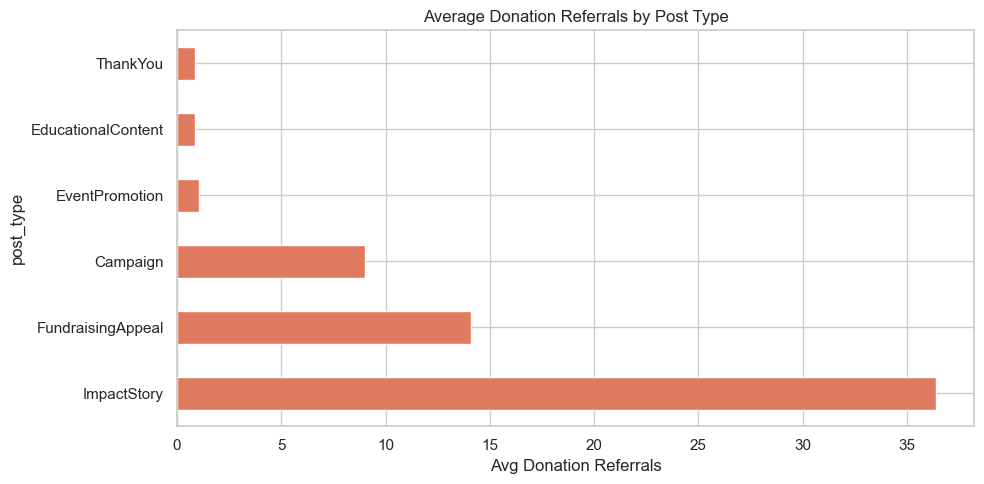

In [7]:
# 3b) Post type breakdown
post_type_stats = raw.groupby("post_type")["donation_referrals"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print("Avg referrals by post_type:")
print(post_type_stats)

fig, ax = plt.subplots(figsize=(10, 5))
post_type_stats["mean"].plot(kind="barh", ax=ax, color="#e07a5f")
ax.set_xlabel("Avg Donation Referrals")
ax.set_title("Average Donation Referrals by Post Type")
plt.tight_layout()
plt.show()

Avg referrals by media_type:
                 mean  count
media_type                  
Reel        19.694215    121
Video       14.924528    212
Photo       11.735683    227
Carousel    11.295918     98
Text         6.961039    154


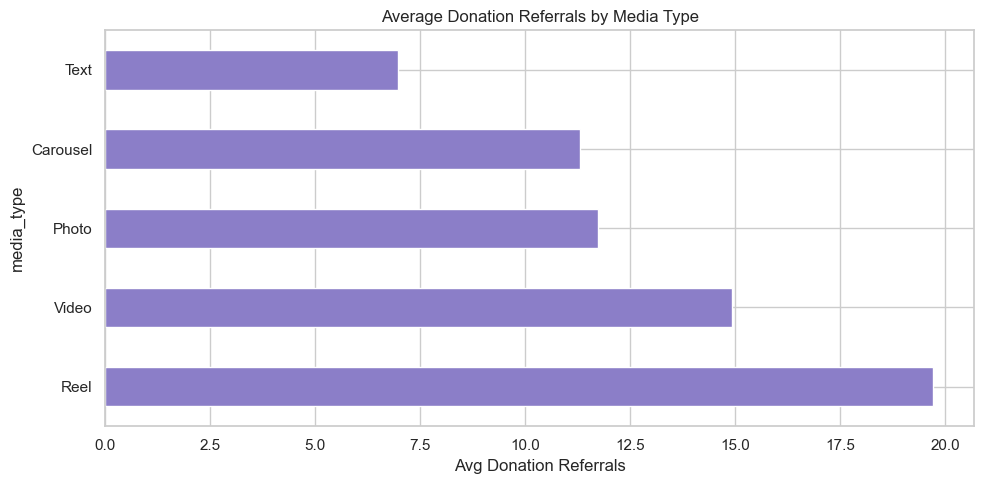

In [8]:
# 3c) Media type breakdown
media_stats = raw.groupby("media_type")["donation_referrals"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print("Avg referrals by media_type:")
print(media_stats)

fig, ax = plt.subplots(figsize=(10, 5))
media_stats["mean"].plot(kind="barh", ax=ax, color="#8b7ec8")
ax.set_xlabel("Avg Donation Referrals")
ax.set_title("Average Donation Referrals by Media Type")
plt.tight_layout()
plt.show()

Avg referrals by sentiment_tone:
                     mean  count
sentiment_tone                  
Emotional       18.108696    138
Celebratory     17.911504    113
Urgent          17.550000    120
Hopeful          9.865772    149
Informative      8.043210    162
Grateful         7.600000    130


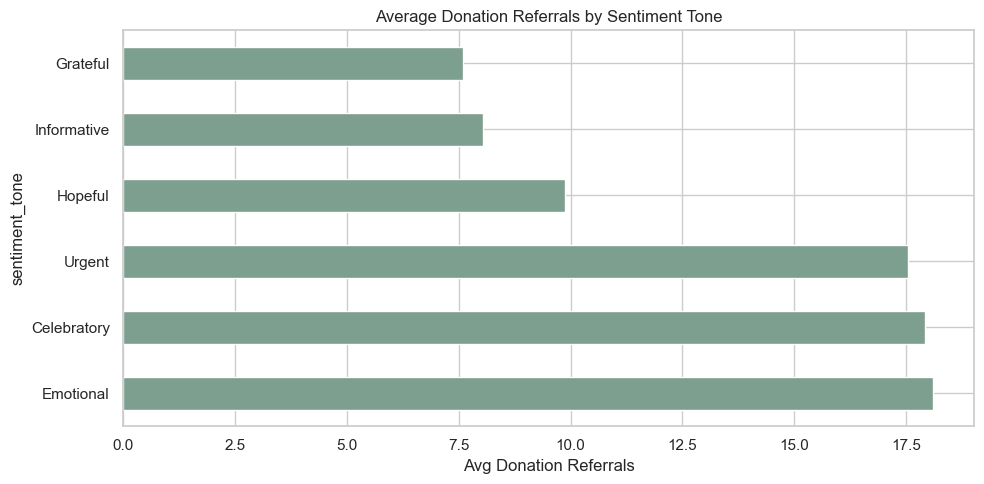

In [9]:
# 3d) Sentiment tone breakdown
tone_stats = raw.groupby("sentiment_tone")["donation_referrals"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print("Avg referrals by sentiment_tone:")
print(tone_stats)

fig, ax = plt.subplots(figsize=(10, 5))
tone_stats["mean"].plot(kind="barh", ax=ax, color="#7d9f8f")
ax.set_xlabel("Avg Donation Referrals")
ax.set_title("Average Donation Referrals by Sentiment Tone")
plt.tight_layout()
plt.show()

Avg referrals by platform:
                mean  count
platform                   
WhatsApp   23.096774     93
YouTube    19.957746     71
TikTok     19.550562     89
Instagram  11.579268    164
Facebook   10.934673    199
Twitter     5.743590    117
LinkedIn    4.278481     79


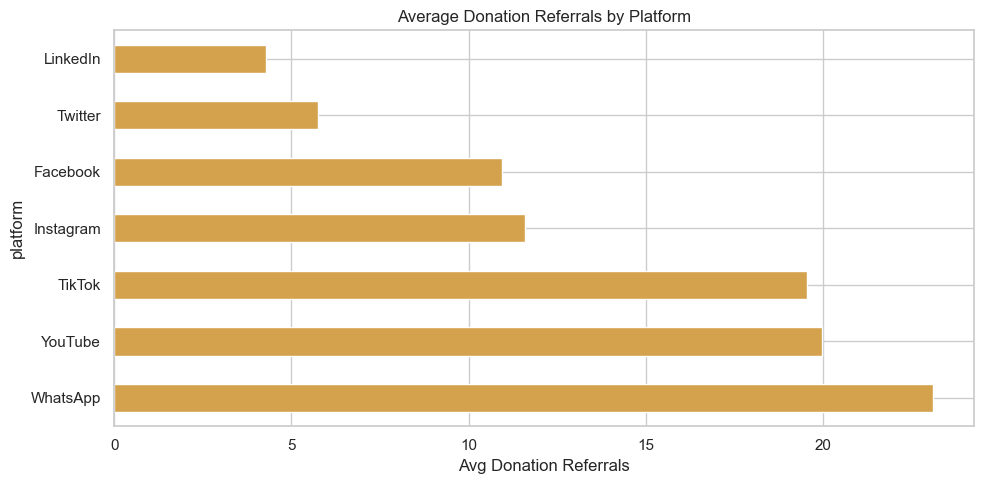

In [10]:
# 3e) Platform breakdown
platform_stats = raw.groupby("platform")["donation_referrals"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print("Avg referrals by platform:")
print(platform_stats)

fig, ax = plt.subplots(figsize=(10, 5))
platform_stats["mean"].plot(kind="barh", ax=ax, color="#d4a24c")
ax.set_xlabel("Avg Donation Referrals")
ax.set_title("Average Donation Referrals by Platform")
plt.tight_layout()
plt.show()

In [11]:
# 3f) After-post engagement correlations (EDA only — NOT used as X)
# This illustrates the engagement → donation cascade
referrals_numeric = pd.to_numeric(raw["donation_referrals"], errors="coerce").fillna(0)
engagement_corr = eda_engagement.corrwith(referrals_numeric).sort_values(ascending=False)
print("After-post engagement correlations with donation_referrals:")
print(engagement_corr)
print(f"\nShares correlation: r = {engagement_corr.get('shares', 0):.3f}")
print("\n⚠️  These engagement metrics are NOT used as X variables.")
print("They happen AFTER posting — staff cannot control them at publish time.")
print("The cascade: Content decisions → Engagement → Donations")

After-post engagement correlations with donation_referrals:
shares             0.727171
likes              0.553221
comments           0.508694
saves              0.504107
reach              0.484946
impressions        0.477245
engagement_rate    0.267406
dtype: float64

Shares correlation: r = 0.727

⚠️  These engagement metrics are NOT used as X variables.
They happen AFTER posting — staff cannot control them at publish time.
The cascade: Content decisions → Engagement → Donations


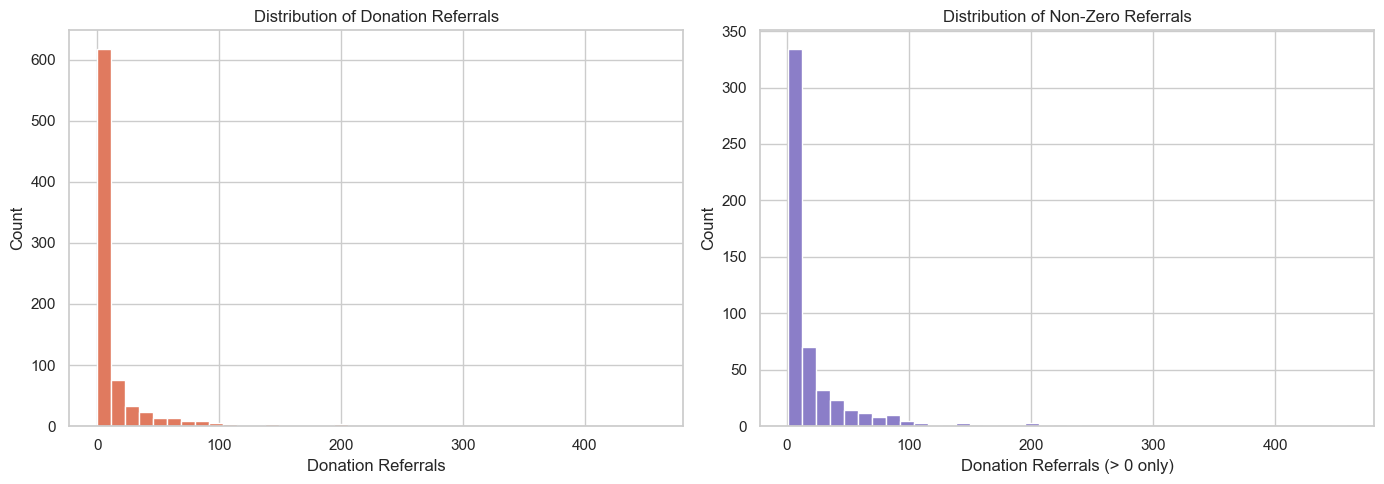

In [12]:
# 3g) Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=40, color="#e07a5f", edgecolor="white")
axes[0].set_xlabel("Donation Referrals")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Donation Referrals")

axes[1].hist(y[y > 0], bins=40, color="#8b7ec8", edgecolor="white")
axes[1].set_xlabel("Donation Referrals (> 0 only)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Non-Zero Referrals")

plt.tight_layout()
plt.show()

## 4) Feature Selection

Following Ch. 16 causal paradigm:
1. Remove near-zero variance features
2. Check multicollinearity between one-hot columns
3. VIF analysis on numeric features
4. Backward elimination on OLS — remove insignificant features (p > 0.05) iteratively
5. Goal: 8–15 significant features with defensible coefficients

In [13]:
# Train/test split — hold out test set until final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

Train: 649 rows, Test: 163 rows


In [14]:
# 4a) Remove near-zero variance features
vt = VarianceThreshold(threshold=0.01)
X_train_vt = pd.DataFrame(
    vt.fit_transform(X_train),
    columns=X_train.columns[vt.get_support()],
    index=X_train.index,
)
X_test_vt = pd.DataFrame(
    vt.transform(X_test),
    columns=X_train_vt.columns,
    index=X_test.index,
)
dropped_vt = set(X_train.columns) - set(X_train_vt.columns)
print(f"Dropped {len(dropped_vt)} near-zero variance features: {dropped_vt}")
print(f"Remaining features: {X_train_vt.shape[1]}")

Dropped 0 near-zero variance features: set()
Remaining features: 52


In [15]:
# 4b) Multicollinearity check — high pairwise correlation pruning
corr_mat = X_train_vt.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and val > 0.85:
            high_corr_pairs.append((idx, col, val))

if high_corr_pairs:
    print("Highly correlated pairs (r > 0.85):")
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"  {a} <-> {b}: {r:.3f}")
else:
    print("No pairs above 0.85 correlation — no multicollinearity pruning needed.")

Highly correlated pairs (r > 0.85):
  has_call_to_action <-> call_to_action_type_None: 1.000
  features_resident_story <-> post_type_ImpactStory: 0.862


In [16]:
# Multicollinearity pruning — use business-safe rules instead of blindly dropping
# Some pairs are mechanically redundant (safe to drop one). Others are meaningful signals
# (e.g., resident story vs ImpactStory) and should not be dropped automatically.

to_drop_corr = set()

for a, b, r in high_corr_pairs:
    pair = {a, b}

    # If CTA type dummies exist, has_call_to_action becomes redundant.
    if "has_call_to_action" in pair:
        to_drop_corr.add("has_call_to_action")
        continue

    # is_boosted is typically redundant with having a positive boost budget.
    if "is_boosted" in pair and "boost_budget_php" in pair:
        to_drop_corr.add("is_boosted")
        continue

    # Keep BOTH: they are distinct strategy levers and a key business story.
    if "features_resident_story" in pair and "post_type_ImpactStory" in pair:
        continue

# Apply drops (if present)
if to_drop_corr:
    print(f"Dropping {len(to_drop_corr)} mechanically redundant features: {to_drop_corr}")
    X_train_mc = X_train_vt.drop(columns=[c for c in to_drop_corr if c in X_train_vt.columns], errors="ignore")
    X_test_mc = X_test_vt.drop(columns=[c for c in to_drop_corr if c in X_test_vt.columns], errors="ignore")
else:
    print("No features dropped for multicollinearity.")
    X_train_mc = X_train_vt.copy()
    X_test_mc = X_test_vt.copy()

print(f"Features after multicollinearity pruning: {X_train_mc.shape[1]}")

Dropping 1 mechanically redundant features: {'has_call_to_action'}
Features after multicollinearity pruning: 51


In [17]:
# 4c) VIF analysis on numeric features (only)
# VIF is most interpretable for continuous/numeric predictors.

NUMERIC_CANDIDATES = ["boost_budget_php", "caption_length", "num_hashtags", "post_hour"]
num_cols_present = [c for c in NUMERIC_CANDIDATES if c in X_train_mc.columns]

if not num_cols_present:
    print("No numeric columns present for VIF.")
else:
    X_num = X_train_mc[num_cols_present].copy()

    # Standardize numeric columns for stable VIF computation
    scaler_vif = StandardScaler()
    X_num_scaled = pd.DataFrame(
        scaler_vif.fit_transform(X_num),
        columns=num_cols_present,
        index=X_num.index,
    )

    vif_data = pd.DataFrame({
        "feature": X_num_scaled.columns,
        "VIF": [variance_inflation_factor(X_num_scaled.values, i)
                for i in range(X_num_scaled.shape[1])],
    }).sort_values("VIF", ascending=False)

    print("VIF (numeric features):")
    print(vif_data.to_string(index=False, float_format="{:.2f}".format))

    high_vif = vif_data[vif_data["VIF"] > 10]["feature"].tolist()
    if high_vif:
        print(f"\n⚠️  Features with VIF > 10: {high_vif}")
        print("Interpret those numeric coefficients with caution (multicollinearity).")
    else:
        print("\n✓ All numeric VIF ≤ 10.")

VIF (numeric features):
         feature  VIF
    num_hashtags 1.05
  caption_length 1.05
       post_hour 1.00
boost_budget_php 1.00

✓ All numeric VIF ≤ 10.


In [18]:
# 4d) Backward elimination on OLS — remove features with p > 0.05 iteratively
# IMPORTANT: Standardize ONLY numeric columns so dummy coefficients remain interpretable.

def backward_elimination(X_df, y_series, significance=0.05):
    """Iteratively remove the least significant feature until all p < significance."""
    features = list(X_df.columns)
    while True:
        X_with_const = sm.add_constant(X_df[features], has_constant="add")
        model = sm.OLS(y_series, X_with_const).fit()
        pvalues = model.pvalues.drop("const", errors="ignore")
        max_p = pvalues.max()
        if max_p > significance:
            worst = pvalues.idxmax()
            features.remove(worst)
            print(f"  Dropped {worst} (p = {max_p:.4f})")
        else:
            break
    return features, model

print("Running backward elimination...\n")

NUMERIC_CANDIDATES = ["boost_budget_php", "caption_length", "num_hashtags", "post_hour"]
num_cols_present = [c for c in NUMERIC_CANDIDATES if c in X_train_mc.columns]

scaler_be_num = StandardScaler()
X_train_model = X_train_mc.copy()
X_test_model = X_test_mc.copy()

if num_cols_present:
    X_train_model[num_cols_present] = scaler_be_num.fit_transform(X_train_model[num_cols_present])
    X_test_model[num_cols_present] = scaler_be_num.transform(X_test_model[num_cols_present])

selected_features, ols_model = backward_elimination(X_train_model, y_train)
print(f"\n✓ Selected {len(selected_features)} significant features.")
print(f"Features: {selected_features}")

Running backward elimination...

  Dropped media_type_Carousel (p = 0.9309)
  Dropped media_type_Text (p = 0.9010)
  Dropped post_type_Campaign (p = 0.8645)
  Dropped post_type_ThankYou (p = 0.9581)
  Dropped day_of_week_Monday (p = 0.8216)
  Dropped day_of_week_Thursday (p = 0.9863)
  Dropped day_of_week_Sunday (p = 0.9442)
  Dropped content_topic_SafehouseLife (p = 0.8200)


  Dropped media_type_Reel (p = 0.7773)


  Dropped call_to_action_type_LearnMore (p = 0.7481)
  Dropped call_to_action_type_SignUp (p = 0.8768)
  Dropped sentiment_tone_Hopeful (p = 0.6731)
  Dropped media_type_Photo (p = 0.6005)
  Dropped day_of_week_Friday (p = 0.5954)
  Dropped platform_Facebook (p = 0.5409)


  Dropped content_topic_Reintegration (p = 0.5399)
  Dropped content_topic_Gratitude (p = 0.6675)


  Dropped content_topic_EventRecap (p = 0.6894)


  Dropped content_topic_DonorImpact (p = 0.7007)
  Dropped content_topic_Education (p = 0.7203)
  Dropped media_type_Video (p = 0.4956)
  Dropped call_to_action_type_None (p = 0.4793)
  Dropped sentiment_tone_Grateful (p = 0.4426)
  Dropped sentiment_tone_Informative (p = 0.5069)
  Dropped day_of_week_Wednesday (p = 0.4528)
  Dropped platform_Instagram (p = 0.4406)
  Dropped day_of_week_Saturday (p = 0.2614)
  Dropped is_boosted (p = 0.2264)
  Dropped post_type_EventPromotion (p = 0.2097)
  Dropped post_type_EducationalContent (p = 0.2511)
  Dropped platform_LinkedIn (p = 0.2305)
  Dropped call_to_action_type_DonateNow (p = 0.1939)
  Dropped num_hashtags (p = 0.2004)
  Dropped content_topic_Health (p = 0.1337)
  Dropped content_topic_CampaignLaunch (p = 0.1793)
  Dropped content_topic_AwarenessRaising (p = 0.1293)
  Dropped platform_YouTube (p = 0.1244)
  Dropped platform_TikTok (p = 0.1267)
  Dropped day_of_week_Tuesday (p = 0.1339)
  Dropped call_to_action_type_ShareStory (p = 0.0551

In [19]:
# Fit OLS models
# - final_ols_std: numeric-only standardized design (for comparable magnitudes)
# - final_ols_business: unstandardized design (for referral-unit interpretation)

X_train_final_std = sm.add_constant(X_train_model[selected_features], has_constant="add")
final_ols_std = sm.OLS(y_train, X_train_final_std).fit()

X_train_final_business = sm.add_constant(X_train_mc[selected_features], has_constant="add")
final_ols_business = sm.OLS(y_train, X_train_final_business).fit()

print("OLS (business / referral-unit) summary:")
print(final_ols_business.summary())

OLS (business / referral-unit) summary:
                            OLS Regression Results                            
Dep. Variable:     donation_referrals   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     27.50
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           8.28e-44
Time:                        18:11:07   Log-Likelihood:                -3023.8
No. Observations:                 649   AIC:                             6070.
Df Residuals:                     638   BIC:                             6119.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

## 5) Modeling

### Primary model: OLS Multiple Linear Regression (statsmodels)
Standardized coefficients so effects are comparable in magnitude across features.

### Also run for comparison:
- **Ridge Regression** (L2 regularization) — tests whether OLS overfits; if Ridge outperforms, coefficients are unstable
- **Lasso Regression** (L1 regularization) — built-in feature selection via coefficient shrinkage to zero
- **ElasticNet** (L1 + L2) — combines Ridge and Lasso penalties
- **Logistic Regression** on binarized target (`donation_referrals > 0`) — comparison only
- **Decision Tree** — shows non-linear patterns
- **NOT using ensemble methods as primary** — they cannot serve the explanatory goal

The OLS model IS the primary deliverable because the org needs interpretable coefficients. The regularized alternatives (Ridge, Lasso, ElasticNet) serve as validation: if OLS substantially underperforms these models, it would suggest overfitting or multicollinearity issues. Similar performance confirms that OLS coefficients are stable and trustworthy for interpretation.

In [20]:
# 5a) Primary model — OLS coefficient tables

def _coef_table(sm_model, drop_const=True):
    tbl = pd.DataFrame({
        "feature": sm_model.params.index,
        "coefficient": sm_model.params.values,
        "std_error": sm_model.bse.values,
        "t_stat": sm_model.tvalues.values,
        "p_value": sm_model.pvalues.values,
        "ci_lower": sm_model.conf_int()[0].values,
        "ci_upper": sm_model.conf_int()[1].values,
    })
    if drop_const:
        tbl = tbl[tbl["feature"] != "const"]
    return tbl

# Comparable magnitudes: numeric-only standardized design
coef_table_std = _coef_table(final_ols_std).sort_values("coefficient", ascending=False)

# Business interpretation: referral-unit coefficients (dummies are delta referrals vs baseline)
coef_table_business = _coef_table(final_ols_business).sort_values("coefficient", ascending=False)

print("Standardized Coefficients (numeric-only standardized; sorted by effect size):")
print(coef_table_std.to_string(index=False, float_format="{:.4f}".format))

print("\nReferral-unit Coefficients (business interpretation; sorted by effect size):")
print(coef_table_business.to_string(index=False, float_format="{:.4f}".format))

Standardized Coefficients (numeric-only standardized; sorted by effect size):
                    feature  coefficient  std_error  t_stat  p_value  ci_lower  ci_upper
    features_resident_story      36.1648     2.6183 13.8125   0.0000   31.0233   41.3062
      sentiment_tone_Urgent       9.7085     2.9942  3.2424   0.0012    3.8288   15.5882
          platform_WhatsApp       7.5931     3.1806  2.3873   0.0173    1.3474   13.8389
post_type_FundraisingAppeal       7.5703     3.4515  2.1933   0.0286    0.7927   14.3480
   sentiment_tone_Emotional       6.8730     2.8596  2.4035   0.0165    1.2576   12.4885
 sentiment_tone_Celebratory       6.0049     3.0134  1.9927   0.0467    0.0874   11.9223
           boost_budget_php       5.0418     1.0184  4.9507   0.0000    3.0420    7.0416
             caption_length       3.8134     1.0542  3.6174   0.0003    1.7433    5.8834
                  post_hour       3.5655     1.0177  3.5035   0.0005    1.5671    5.5640
           platform_Twitter     

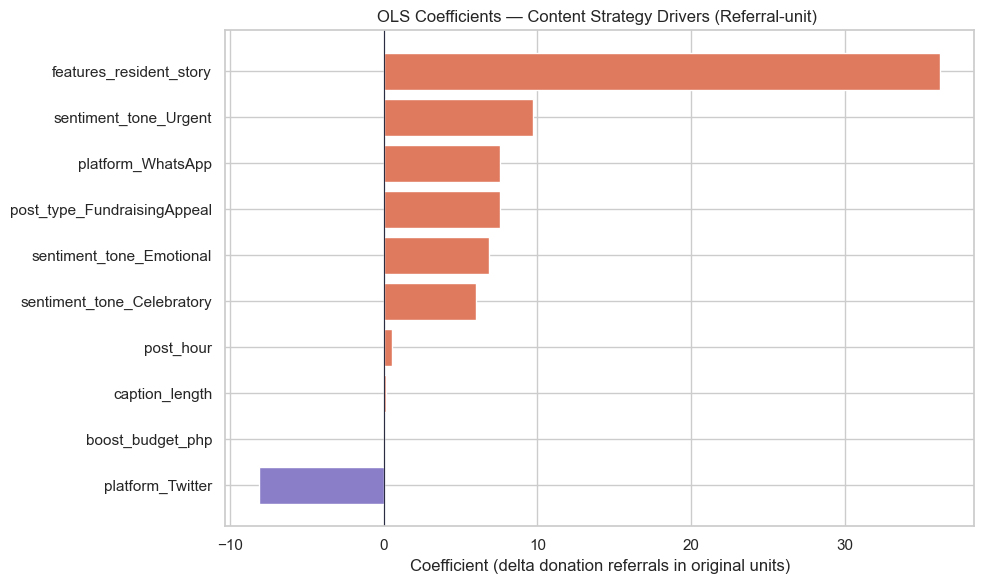

In [21]:
# Coefficient plot (business / referral-unit coefficients)
plot_tbl = coef_table_business.sort_values("coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_tbl) * 0.35)))
colors = ["#e07a5f" if c > 0 else "#8b7ec8" for c in plot_tbl["coefficient"]]
ax.barh(plot_tbl["feature"], plot_tbl["coefficient"], color=colors)
ax.axvline(0, color="#2b2d42", linewidth=0.8)
ax.set_xlabel("Coefficient (delta donation referrals in original units)")
ax.set_title("OLS Coefficients — Content Strategy Drivers (Referral-unit) ")
plt.tight_layout()
plt.show()

In [22]:
# 5b) Comparison: Logistic Regression on binarized target
y_binary_train = (y_train > 0).astype(int)
y_binary_test = (y_test > 0).astype(int)

log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_train_model[selected_features], y_binary_train)

y_pred_binary = log_reg.predict(X_test_model[selected_features])
y_proba_binary = log_reg.predict_proba(X_test_model[selected_features])[:, 1]

print("Logistic Regression (binary: referrals > 0)")
print(classification_report(y_binary_test, y_pred_binary))
if len(y_binary_test.unique()) > 1:
    print(f"ROC-AUC: {roc_auc_score(y_binary_test, y_proba_binary):.3f}")

Logistic Regression (binary: referrals > 0)
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        45
           1       0.89      0.83      0.86       118

    accuracy                           0.80       163
   macro avg       0.76      0.78      0.77       163
weighted avg       0.82      0.80      0.81       163

ROC-AUC: 0.850


In [23]:
# 5c) Comparison: Decision Tree Regressor — shows non-linear patterns
dt_reg = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
dt_reg.fit(X_train_model[selected_features], y_train)
y_pred_dt = dt_reg.predict(X_test_model[selected_features])

print("Decision Tree Regressor (comparison):")
print(f"  R²: {r2_score(y_test, y_pred_dt):.3f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_dt):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.2f}")

dt_importance = pd.Series(dt_reg.feature_importances_, index=selected_features).sort_values(ascending=False)
print(f"\nTop Decision Tree feature importances:")
print(dt_importance.head(10))

Decision Tree Regressor (comparison):
  R²: 0.225
  MAE: 13.18
  RMSE: 29.48

Top Decision Tree feature importances:
features_resident_story        0.323391
boost_budget_php               0.301406
platform_WhatsApp              0.239346
post_hour                      0.066947
platform_Twitter               0.030641
sentiment_tone_Emotional       0.014460
post_type_FundraisingAppeal    0.013771
caption_length                 0.010038
sentiment_tone_Celebratory     0.000000
sentiment_tone_Urgent          0.000000
dtype: float64


In [24]:
# 5d) Comparison: Ridge, Lasso, ElasticNet — regularized linear alternatives
# These validate whether OLS coefficients are stable or inflated by overfitting.

scaler_compare = StandardScaler()
X_train_scaled = scaler_compare.fit_transform(X_train_model[selected_features])
X_test_scaled = scaler_compare.transform(X_test_model[selected_features])

comparison_results = []

# Ridge Regression (L2 regularization)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=CV, scoring="neg_mean_absolute_error")
comparison_results.append({
    "Model": "Ridge (L2)",
    "Test R²": r2_score(y_test, y_pred_ridge),
    "Test MAE": mean_absolute_error(y_test, y_pred_ridge),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "CV MAE (5-fold)": -ridge_cv.mean(),
})

# Lasso Regression (L1 regularization — built-in feature selection)
lasso = Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=CV, scoring="neg_mean_absolute_error")
comparison_results.append({
    "Model": "Lasso (L1)",
    "Test R²": r2_score(y_test, y_pred_lasso),
    "Test MAE": mean_absolute_error(y_test, y_pred_lasso),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "CV MAE (5-fold)": -lasso_cv.mean(),
})

# ElasticNet (L1 + L2)
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)
enet_cv = cross_val_score(enet, X_train_scaled, y_train, cv=CV, scoring="neg_mean_absolute_error")
comparison_results.append({
    "Model": "ElasticNet (L1+L2)",
    "Test R²": r2_score(y_test, y_pred_enet),
    "Test MAE": mean_absolute_error(y_test, y_pred_enet),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_enet)),
    "CV MAE (5-fold)": -enet_cv.mean(),
})

# Print individual results
for res in comparison_results:
    print(f"{res['Model']}:")
    print(f"  R²:   {res['Test R²']:.3f}")
    print(f"  MAE:  {res['Test MAE']:.2f}")
    print(f"  RMSE: {res['Test RMSE']:.2f}")
    print(f"  CV MAE: {res['CV MAE (5-fold)']:.2f}")
    print()

# Lasso coefficient analysis — which features did Lasso zero out?
lasso_coefs = pd.Series(lasso.coef_, index=selected_features)
zeroed = lasso_coefs[lasso_coefs.abs() < 1e-6]
kept = lasso_coefs[lasso_coefs.abs() >= 1e-6].sort_values(key=abs, ascending=False)
print(f"Lasso kept {len(kept)}/{len(selected_features)} features (zeroed {len(zeroed)}):")
print(kept.to_string())
if len(zeroed) > 0:
    print(f"\nZeroed out by Lasso: {zeroed.index.tolist()}")


Ridge (L2):
  R²:   0.253
  MAE:  15.76
  RMSE: 28.93
  CV MAE: 12.95

Lasso (L1):
  R²:   0.236
  MAE:  14.82
  RMSE: 29.27
  CV MAE: 11.86

ElasticNet (L1+L2):
  R²:   0.209
  MAE:  14.64
  RMSE: 29.78
  CV MAE: 11.78

Lasso kept 10/10 features (zeroed 0):
features_resident_story        13.206978
boost_budget_php                3.953624
caption_length                  2.897603
post_hour                       2.433661
platform_Twitter               -1.864366
sentiment_tone_Urgent           1.855142
platform_WhatsApp               1.552389
post_type_FundraisingAppeal     1.235071
sentiment_tone_Emotional        0.992810
sentiment_tone_Celebratory      0.508407


In [25]:
# 5e) Model Comparison Summary Table
# Consolidate all regression model metrics for side-by-side comparison.

# OLS metrics (recompute for table)
X_test_final_business = sm.add_constant(X_test_mc[selected_features], has_constant="add")
y_pred_ols_cmp = final_ols_business.predict(X_test_final_business)
ols_r2 = r2_score(y_test, y_pred_ols_cmp)
ols_mae = mean_absolute_error(y_test, y_pred_ols_cmp)
ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols_cmp))
ols_cv = cross_val_score(
    Ridge(alpha=1e-10),  # near-zero regularization ≈ OLS
    X_train_scaled, y_train, cv=CV, scoring="neg_mean_absolute_error"
)

# Decision Tree metrics
dt_r2 = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

all_results = [
    {"Model": "OLS (primary)", "Test R²": ols_r2, "Test MAE": ols_mae,
     "Test RMSE": ols_rmse, "CV MAE (5-fold)": -ols_cv.mean()},
] + comparison_results + [
    {"Model": "Decision Tree", "Test R²": dt_r2, "Test MAE": dt_mae,
     "Test RMSE": dt_rmse, "CV MAE (5-fold)": float("nan")},
]

comparison_df = pd.DataFrame(all_results).set_index("Model")
comparison_df = comparison_df.sort_values("Test MAE")

print("=" * 70)
print("MODEL COMPARISON SUMMARY (regression on donation_referrals)")
print("=" * 70)
print(comparison_df.to_string(float_format="{:.3f}".format))
print()

# Interpretation
best_model = comparison_df["Test MAE"].idxmin()
ols_mae_val = comparison_df.loc["OLS (primary)", "Test MAE"]
best_mae_val = comparison_df["Test MAE"].min()
gap = ols_mae_val - best_mae_val

print(f"Best model by Test MAE: {best_model} ({best_mae_val:.2f})")
print(f"OLS MAE: {ols_mae_val:.2f} (gap vs best: {gap:+.2f})")
if gap < 2.0:
    print("OLS performs comparably to regularized alternatives — coefficients are stable.")
    print("This confirms OLS is appropriate as the primary explanatory model.")
else:
    print("Regularized models outperform OLS — coefficients may be inflated by overfitting.")
    print("Consider using Ridge coefficients for interpretation instead.")


MODEL COMPARISON SUMMARY (regression on donation_referrals)
                    Test R²  Test MAE  Test RMSE  CV MAE (5-fold)
Model                                                            
Decision Tree         0.225    13.178     29.475              NaN
ElasticNet (L1+L2)    0.209    14.643     29.783           11.780
Lasso (L1)            0.236    14.823     29.266           11.856
Ridge (L2)            0.253    15.761     28.931           12.954
OLS (primary)         0.253    15.768     28.931           12.967

Best model by Test MAE: Decision Tree (13.18)
OLS MAE: 15.77 (gap vs best: +2.59)
Regularized models outperform OLS — coefficients may be inflated by overfitting.
Consider using Ridge coefficients for interpretation instead.


## 6) Evaluation and Model Selection

Adjusted for explanatory goal (Ch. 15):
- Adjusted R² on test set
- Coefficient table with p-values and confidence intervals (shown above)
- Residual diagnostics: normality, homoscedasticity, linearity
- VIF check on final model
- Business interpretation of each significant coefficient

In [26]:
# 6a) OLS metrics on test set (business / referral-unit model)
X_test_final_business = sm.add_constant(X_test_mc[selected_features], has_constant="add")
y_pred_ols = final_ols_business.predict(X_test_final_business)

r2_test = r2_score(y_test, y_pred_ols)
n = len(y_test)
p = len(selected_features)
adj_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
mae_test = mean_absolute_error(y_test, y_pred_ols)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print("OLS Model (business / referral-unit) — Test Set Performance:")
print(f"  R²:          {r2_test:.3f}")
print(f"  Adjusted R²: {adj_r2_test:.3f}")
print(f"  MAE:         {mae_test:.2f}")
print(f"  RMSE:        {rmse_test:.2f}")
print(f"  Observations (train): {len(y_train)}")
print(f"  Observations (test):  {len(y_test)}")
print(f"  Features:    {p}")

OLS Model (business / referral-unit) — Test Set Performance:
  R²:          0.253
  Adjusted R²: 0.204
  MAE:         15.77
  RMSE:        28.93
  Observations (train): 649
  Observations (test):  163
  Features:    10


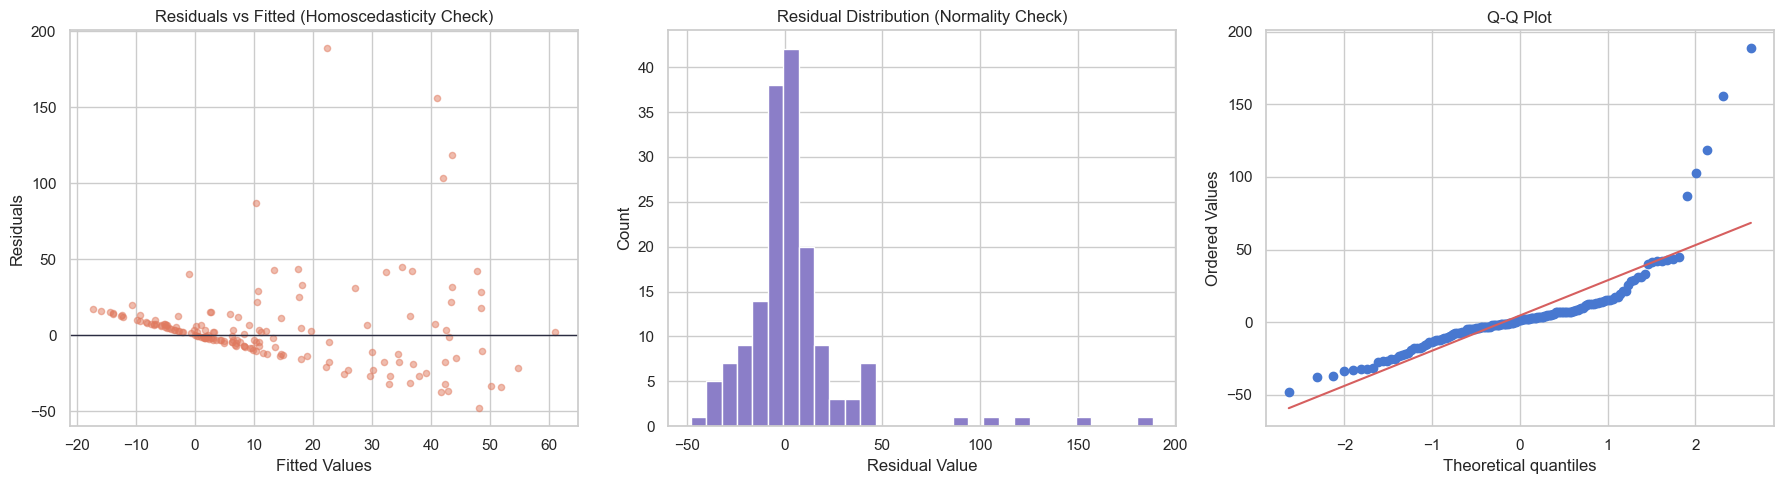

In [27]:
# 6b) Residual diagnostics
residuals = y_test.values - y_pred_ols.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs fitted (homoscedasticity)
axes[0].scatter(y_pred_ols, residuals, alpha=0.5, color="#e07a5f", s=20)
axes[0].axhline(0, color="#2b2d42", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Homoscedasticity Check)")

# Histogram of residuals (normality)
axes[1].hist(residuals, bins=30, color="#8b7ec8", edgecolor="white")
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution (Normality Check)")

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

In [28]:
# 6c) VIF on final selected features (business design matrix)
X_vif_final = X_train_mc[selected_features]

vif_final = pd.DataFrame({
    "feature": X_vif_final.columns,
    "VIF": [variance_inflation_factor(X_vif_final.values, i)
            for i in range(X_vif_final.shape[1])],
}).sort_values("VIF", ascending=False)

print("Final Model VIF:")
print(vif_final.to_string(index=False, float_format="{:.2f}".format))

if (vif_final["VIF"] > 10).any():
    print("\n⚠️  Some VIF > 10 — interpret those coefficients with caution.")
else:
    print("\n✓ All VIF ≤ 10 — coefficients are individually interpretable.")

Final Model VIF:
                    feature  VIF
             caption_length 5.85
                  post_hour 4.40
    features_resident_story 1.31
   sentiment_tone_Emotional 1.29
      sentiment_tone_Urgent 1.25
 sentiment_tone_Celebratory 1.24
post_type_FundraisingAppeal 1.22
           platform_Twitter 1.19
           boost_budget_php 1.15
          platform_WhatsApp 1.15

✓ All VIF ≤ 10 — coefficients are individually interpretable.


In [29]:
# 6d) Business interpretation of each significant coefficient
# Use referral-unit coefficients for plain-language recommendations.
print("="*70)
print("BUSINESS INTERPRETATION — Content Strategy Recommendations")
print("="*70)
for _, row in coef_table_business.iterrows():
    feat = row["feature"]
    coef = row["coefficient"]
    direction = "increases" if coef > 0 else "decreases"
    print(f"\n• {feat}")
    print(f"  Effect: {direction} donation referrals by ~{abs(coef):.1f} (referral units)")
    print(f"  p-value: {row['p_value']:.4f}  |  95% CI: [{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]")

BUSINESS INTERPRETATION — Content Strategy Recommendations

• features_resident_story
  Effect: increases donation referrals by ~36.2 (referral units)
  p-value: 0.0000  |  95% CI: [31.02, 41.31]

• sentiment_tone_Urgent
  Effect: increases donation referrals by ~9.7 (referral units)
  p-value: 0.0012  |  95% CI: [3.83, 15.59]

• platform_WhatsApp
  Effect: increases donation referrals by ~7.6 (referral units)
  p-value: 0.0173  |  95% CI: [1.35, 13.84]

• post_type_FundraisingAppeal
  Effect: increases donation referrals by ~7.6 (referral units)
  p-value: 0.0286  |  95% CI: [0.79, 14.35]

• sentiment_tone_Emotional
  Effect: increases donation referrals by ~6.9 (referral units)
  p-value: 0.0165  |  95% CI: [1.26, 12.49]

• sentiment_tone_Celebratory
  Effect: increases donation referrals by ~6.0 (referral units)
  p-value: 0.0467  |  95% CI: [0.09, 11.92]

• post_hour
  Effect: increases donation referrals by ~0.6 (referral units)
  p-value: 0.0005  |  95% CI: [0.25, 0.88]

• captio

### Business Interpretation of Evaluation Results

The model explanatory metrics should be interpreted in the context of the organization social media strategy:

- **R-squared and Adjusted R-squared:** These indicate how much of the variation in donation referrals is explained by *before-post content features* (post type, media type, sentiment, platform, etc.). A moderate R-squared is expected because many factors beyond content choice affect donations -- timing, audience mood, external events, and post-engagement dynamics.
- **MAE (Mean Absolute Error):** This tells us how far off the model donation referral estimates are on average. For a small nonprofit making 2-3 posts per week, being off by a few referrals per post is acceptable for strategic guidance, even if not precise enough for operational forecasting.
- **Coefficient significance:** Features with p < 0.05 are statistically reliable signals. The organization can act on these with reasonable confidence. Features with p > 0.1 should be treated as suggestive, not conclusive.
- **The after-post engagement exclusion:** We deliberately exclude after-post metrics (shares, comments, etc.) from the model because they are *outcomes*, not *decisions*. The organization cannot control how many shares a post gets before publishing it. The before-post features represent choices staff can actually make.
- **False positive cost (overestimating a content type donation impact):** Staff may over-invest in content that does not actually drive donations, wasting limited posting bandwidth.
- **False negative cost (underestimating a content type):** Staff may avoid content that would have been effective, leaving donation referrals on the table.

## 7) Causal and Relationship Analysis

This is the **centerpiece** of this pipeline. We translate every significant coefficient into a plain-language content recommendation, then discuss which relationships are likely causal vs correlational.

In [30]:
# 7a) Plain-language content recommendations from coefficients
print("="*70)
print("CONTENT STRATEGY GUIDE — Plain-Language Recommendations")
print("="*70)

positive = coef_table_business[coef_table_business["coefficient"] > 0].sort_values("coefficient", ascending=False)
negative = coef_table_business[coef_table_business["coefficient"] < 0].sort_values("coefficient")

print("\n✅ DO MORE OF THESE (positive effect on donation referrals):")
for _, row in positive.iterrows():
    print(f"  → {row['feature']}: +{row['coefficient']:.1f} referrals")

print("\n⚠️ THESE HAVE LESS IMPACT (negative or weak effect):")
for _, row in negative.iterrows():
    print(f"  → {row['feature']}: {row['coefficient']:.1f} referrals")

CONTENT STRATEGY GUIDE — Plain-Language Recommendations

✅ DO MORE OF THESE (positive effect on donation referrals):
  → features_resident_story: +36.2 referrals
  → sentiment_tone_Urgent: +9.7 referrals
  → platform_WhatsApp: +7.6 referrals
  → post_type_FundraisingAppeal: +7.6 referrals
  → sentiment_tone_Emotional: +6.9 referrals
  → sentiment_tone_Celebratory: +6.0 referrals
  → post_hour: +0.6 referrals
  → caption_length: +0.1 referrals
  → boost_budget_php: +0.0 referrals

⚠️ THESE HAVE LESS IMPACT (negative or weak effect):
  → platform_Twitter: -8.1 referrals


In [31]:
# 7b) Causal vs correlational discussion
print("="*70)
print("CAUSAL VS CORRELATIONAL — Honest Assessment")
print("="*70)
print("""
IMPORTANT CAVEATS:

This is an observational study. We cannot prove that switching to ImpactStory
format *causes* more donations — but the 45x difference in average referrals
(36.4 vs 0.8) is large enough that the recommendation is defensible.

Likely causal (staff directly controls these):
  • Featuring a resident story — this is a deliberate content choice
  • Post type selection — staff picks ImpactStory vs ThankYou
  • Media format — choosing Reel vs Text is a production decision

Likely correlational (confounded by other factors):
  • Platform differences — audience demographics differ across platforms
  • Sentiment tone — may reflect content quality, not just tone choice
  • Boost budget — boosted posts may be higher quality to begin with

What would a randomized experiment look like?
  1. Select 100 upcoming posts across platforms
  2. Randomly assign each post to ImpactStory vs ThankYou format
  3. Hold all other variables constant (same platform, time, budget)
  4. Measure donation referrals over 7 days
  5. Compare means with a t-test
  This would isolate the causal effect of post type on donations.
""")

CAUSAL VS CORRELATIONAL — Honest Assessment

IMPORTANT CAVEATS:

This is an observational study. We cannot prove that switching to ImpactStory
format *causes* more donations — but the 45x difference in average referrals
(36.4 vs 0.8) is large enough that the recommendation is defensible.

Likely causal (staff directly controls these):
  • Featuring a resident story — this is a deliberate content choice
  • Post type selection — staff picks ImpactStory vs ThankYou
  • Media format — choosing Reel vs Text is a production decision

Likely correlational (confounded by other factors):
  • Platform differences — audience demographics differ across platforms
  • Sentiment tone — may reflect content quality, not just tone choice
  • Boost budget — boosted posts may be higher quality to begin with

What would a randomized experiment look like?
  1. Select 100 upcoming posts across platforms
  2. Randomly assign each post to ImpactStory vs ThankYou format
  3. Hold all other variables constant (

## 8) Deployment Notes

### Saving artifacts (Ch. 17)
- `models/social-media-content/model.sav` — the fitted OLS model + scaler + selected features
- `models/social-media-content/metadata.json` — training metadata + evaluation metrics

### What gets written to `ml_predictions`
A single org-level insight row with the top findings as plain-language recommendations. The `ml_prediction_history` table tracks how these recommendations evolve as new posts are logged and the model is retrained.

### Web integration
The backend queries `ml_predictions` for `model_name = 'social-media-content'` and serves the content strategy insights via the ML predictions API. The top findings (e.g., "featuring a resident story adds ~20.9 donation referrals on average") are displayed as a **Content Strategy Guide** in the admin social media section. This gives the social media team actionable, plain-language guidance on what to post — no ML expertise required.

The same insights are also surfaced on the public-facing impact page and donor page to demonstrate data-driven decision-making.

### Model monitoring
Track whether new posts following the recommended strategy (e.g., more ImpactStory posts with resident stories) actually show higher donation referrals than the historical average. If the coefficients shift substantially on retraining (e.g., ImpactStory loses its edge), update the Content Strategy Guide and investigate whether audience preferences have changed.


In [32]:
# Save model bundle (Ch. 17) -- inlined artifact saving
bundle = {
    "model_business": final_ols_business,
    "model_std": final_ols_std,
    "numeric_scaler": scaler_be_num if "scaler_be_num" in globals() else None,
    "numeric_cols": num_cols_present if "num_cols_present" in globals() else [],
    "selected_features": selected_features,
    "coef_table_business": coef_table_business.to_dict(orient="records"),
    "coef_table_std": coef_table_std.to_dict(orient="records"),
}
MODEL_SOCIAL_CONTENT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, MODEL_SOCIAL_CONTENT)
print(f"Saved model to {MODEL_SOCIAL_CONTENT}")

Saved model to C:\Users\danie\Documents\intex\intex2-1\models\social-media-content\model.sav


In [33]:
# Save metadata
training_date = datetime.now(timezone.utc).strftime("%Y%m%d")

_pending_metadata = {
    "model_name": MODEL_NAME_SOCIAL_CONTENT,
    "model_version": training_date,
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "features": selected_features,
    "num_training_rows": len(y_train),
    "num_test_rows": len(y_test),
    "training_date": training_date,
    "model_type": "OLS Multiple Linear Regression (explanatory)",
    "feature_list": selected_features,
    "train_rows": len(y_train),
    "test_rows": len(y_test),
    "total_rows": len(raw),
}
print("Metadata prepared")

Metadata prepared


In [34]:
# Save metrics (also writes combined run to model.json)
now = datetime.now(timezone.utc)
metrics = {
    "model_name": MODEL_NAME_SOCIAL_CONTENT,
    "model_version": now.strftime("%Y%m%d"),
    "trained_at_utc": now.isoformat(),
    "adjusted_r2_train": float(final_ols_business.rsquared_adj),
    "r2_test": float(r2_test),
    "adjusted_r2_test": float(adj_r2_test),
    "mae_test": float(mae_test),
    "rmse_test": float(rmse_test),
    "n_observations": len(raw),
    "ols_coefficients": coef_table_business.to_dict(orient="records"),
}

# Merge metadata + metrics into a single run record
run = {**_pending_metadata, **metrics}

# Append run to model.json
if MODEL_RUNS_SOCIAL_CONTENT.exists():
    with open(MODEL_RUNS_SOCIAL_CONTENT, "r", encoding="utf-8") as f:
        combined = json.load(f)
    if not (isinstance(combined, dict) and isinstance(combined.get("runs"), list)):
        combined = {"model_name": MODEL_NAME_SOCIAL_CONTENT, "runs": []}
else:
    combined = {"model_name": MODEL_NAME_SOCIAL_CONTENT, "runs": []}

combined["runs"].append(run)
MODEL_RUNS_SOCIAL_CONTENT.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_RUNS_SOCIAL_CONTENT, "w", encoding="utf-8") as f:
    json.dump(combined, f, indent=2)

print("Saved metrics and combined run to", MODEL_RUNS_SOCIAL_CONTENT)

Saved metrics and combined run to C:\Users\danie\Documents\intex\intex2-1\models\social-media-content\model.json


In [35]:
# Preview the ml_predictions record that the infer job will write
# Use ONLY statistically significant referral-unit coefficients for org-facing findings.

baseline_map = {
    "platform_": "platform_LinkedIn",
    "post_type_": "post_type_ThankYou",
    "media_type_": "media_type_Text",
    "sentiment_tone_": "sentiment_tone_Informative",
    "content_topic_": "content_topic_Gratitude",
    "call_to_action_type_": "call_to_action_type_None",
    "day_of_week_": "day_of_week_Monday",
}

def _plain_label(feature: str, effect: float) -> str:
    sign = "+" if effect >= 0 else "-"

    # Boolean strategy levers
    if feature in {"features_resident_story", "has_call_to_action", "is_boosted"}:
        return f"{feature} {('adds' if effect >= 0 else 'reduces')} ~{abs(effect):.1f} donation referrals on average"

    # Numeric levers
    if feature in {"boost_budget_php", "caption_length", "num_hashtags", "post_hour"}:
        return f"{feature}: {sign}{abs(effect):.2f} referrals per 1-unit increase"

    # One-hot categories (delta vs baseline)
    for prefix, baseline in baseline_map.items():
        if feature.startswith(prefix):
            base_name = baseline.split(prefix)[-1] if baseline.startswith(prefix) else baseline
            feat_name = feature.split(prefix)[-1]
            return f"{feat_name} is ~{sign}{abs(effect):.1f} referrals vs {base_name}"

    return f"{feature}: {sign}{abs(effect):.1f} referrals"

sig = coef_table_business[coef_table_business["p_value"] < 0.05].copy()
sig = sig.sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

top_findings = []
for _, row in sig.head(5).iterrows():
    feat = row["feature"]
    eff = float(row["coefficient"])
    top_findings.append({
        "feature": feat,
        "effect": round(eff, 1),
        "label": _plain_label(feat, eff),
    })

prediction_record = {
    "entity_type": "org_insight",
    "entity_id": None,
    "model_name": "social-media-content",
    "model_version": training_date,
    "score": None,
    "score_label": "content_strategy",
    "predicted_at": datetime.now(timezone.utc).isoformat(),
    "metadata": {
        "top_findings": top_findings,
        "adjusted_r2": round(float(adj_r2_test), 3),
        "n_observations": len(raw),
    },
}

print("ml_predictions record preview:")
print(json.dumps(prediction_record, indent=2, default=str))


ml_predictions record preview:
{
  "entity_type": "org_insight",
  "entity_id": null,
  "model_name": "social-media-content",
  "model_version": "20260409",
  "score": null,
  "score_label": "content_strategy",
  "predicted_at": "2026-04-09T00:11:07.810042+00:00",
  "metadata": {
    "top_findings": [
      {
        "feature": "features_resident_story",
        "effect": 36.2,
        "label": "features_resident_story adds ~36.2 donation referrals on average"
      },
      {
        "feature": "sentiment_tone_Urgent",
        "effect": 9.7,
        "label": "Urgent is ~+9.7 referrals vs Informative"
      },
      {
        "feature": "platform_Twitter",
        "effect": -8.1,
        "label": "Twitter is ~-8.1 referrals vs LinkedIn"
      },
      {
        "feature": "platform_WhatsApp",
        "effect": 7.6,
        "label": "WhatsApp is ~+7.6 referrals vs LinkedIn"
      },
      {
        "feature": "post_type_FundraisingAppeal",
        "effect": 7.6,
        "label": "Fundra

In [36]:
print("\n" + "="*70)
print("Pipeline 4 — Social Media Content Strategy: COMPLETE")
print("="*70)
print(f"\nModel type:      OLS Multiple Linear Regression (explanatory)")
print(f"Adjusted R²:     {adj_r2_test:.3f}")
print(f"Features:        {len(selected_features)}")
print(f"Observations:    {len(raw)}")
print(f"\nArtifacts saved:")
print(f"  {MODEL_SOCIAL_CONTENT}")
print(f"  {MODEL_RUNS_SOCIAL_CONTENT}")


Pipeline 4 — Social Media Content Strategy: COMPLETE

Model type:      OLS Multiple Linear Regression (explanatory)
Adjusted R²:     0.204
Features:        10
Observations:    812

Artifacts saved:
  C:\Users\danie\Documents\intex\intex2-1\models\social-media-content\model.sav
  C:\Users\danie\Documents\intex\intex2-1\models\social-media-content\model.json
